Copy test subset of cropped image data over to this directory

In [7]:
from pathlib import Path
import pandas as pd

crop_type =  "cube_50" # "centroid"

from_directory = Path(f"/home/bioinf/bhklab/radiomics/readii-negative-controls/procdata/RADCURE/readii_{crop_type}_crop")
proc_data_path = Path(f"procdata/RADCURE/images/")

patient_ID_list_file = Path("./rawdata/RADCURE/clinical/col_test_patient_IDs_RADCURE.csv")
test_pat_ids = pd.read_csv(patient_ID_list_file, header=None, names=["pat_id"])

In [8]:
import shutil

cropped_image_path = proc_data_path / "cropped_images" / f"cropped_{crop_type}"

for path in sorted(from_directory.iterdir()):
    pat_id = path.stem[-12:]
    if pat_id in test_pat_ids["pat_id"].unique():
        dest_path = cropped_image_path / pat_id
        if not dest_path.exists():
            destination = shutil.copytree(path, dest_path, dirs_exist_ok=True)

In [9]:
test_pats = pd.Index(test_pat_ids['pat_id'])
cropped_pats = pd.Index([path.stem[-12:] for path in sorted(from_directory.iterdir())])

test_pats.difference(cropped_pats)

Index(['RADCURE-0521', 'RADCURE-0862', 'RADCURE-1096', 'RADCURE-1486',
       'RADCURE-1504', 'RADCURE-1678', 'RADCURE-1694', 'RADCURE-1759',
       'RADCURE-3266', 'RADCURE-3309', 'RADCURE-3344', 'RADCURE-3441',
       'RADCURE-3496', 'RADCURE-3625', 'RADCURE-3632', 'RADCURE-3671',
       'RADCURE-3799', 'RADCURE-3801', 'RADCURE-3918', 'RADCURE-4035',
       'RADCURE-4070'],
      dtype='object')

In [10]:
from readii.io.loaders.general import loadImageDatasetConfig
import itertools

config = loadImageDatasetConfig("RADCURE", Path("config"))

DATASET_NAME = config["dataset_name"]
NEG_CONTROL_REGIONS = config["negative_control_regions"]
NEG_CONTROL_TYPES = config["negative_control_types"]

# Get full list of image types to run FMCIB on
negative_controls = [f"{negative_control[0]}_{negative_control[1]}" for negative_control in itertools.product(NEG_CONTROL_TYPES, NEG_CONTROL_REGIONS)]
image_types = ["original"] + negative_controls

In [11]:
for image_type in image_types:
    fmcib_input_df = pd.DataFrame(columns=['image_path', 'coordX', 'coordY', 'coordZ'])
    fmcib_input_df['image_path'] = [pat_id / f"{image_type}.nii.gz" for pat_id in sorted(cropped_image_path.iterdir())]
    fmcib_input_df["coordX"] = 0
    fmcib_input_df["coordY"] = 0
    fmcib_input_df["coordZ"] = 0

    fmcib_input_df.to_csv(Path(proc_data_path, "fmcib_input", f"cropped_{crop_type}", f"fmcib_input_{DATASET_NAME}_{image_type}.csv"), index=False)

In [ ]:
# INPUT THE PATH TO THE RADCURE IMAGE DATA
downloaded_images_dir = Path("/home/bioinf/bhklab/radiomics/radiomics_orcestra/rawdata/RADCURE/images/zipped")

In [ ]:
patient_ID_list_file = Path("./rawdata/RADCURE/clinical/col_test_patient_IDs_RADCURE.csv")
copy_dir_path = Path(raw_images_dir)

with open(patient_ID_list_file, "r") as f:
    pat_list = csv.reader(f)
    for row in pat_list:
        patient_ID = row[0]

        existing_patient_image_directory = downloaded_images_dir / patient_ID
        copy_patient_image_directory = copy_dir_path / patient_ID

        if copy_patient_image_directory.exists():
            print(f"Copy of {patient_ID}'s image file already exists.")
        else:
            destination = shutil.copytree(existing_patient_image_directory, copy_patient_image_directory, dirs_exist_ok=True)

In [ ]:
# Unzip the files - copy this to shell
# find "rawdata/RADCURE/images" -name "*.zip" | while read filename; do unzip -o -d "`dirname "$filename"`" "$filename"; done;

# Crop method comparison

In [5]:
import SimpleITK as sitk
import sys; sys.path.append("..")
from process_crop import find_bbox, find_centroid, crop_centroid, crop_bbox, crop_maxdim_cube, resize_image
from readii.image_processing import displayImageSlice

In [2]:
ct_path = "/Users/katyscott/Documents/READII-2-ROQC/readii-fmcib/archive/temp_complete_output/procdata/RADCURE/images/mit_outputs/0_RADCURE-0020/CT/CT.nii.gz"
mask_path = "/Users/katyscott/Documents/READII-2-ROQC/readii-fmcib/archive/temp_complete_output/procdata/RADCURE/images/mit_outputs/0_RADCURE-0020/RTSTRUCT_CT/GTV.nii.gz"

image = sitk.ReadImage(ct_path)
mask = sitk.ReadImage(mask_path)

In [9]:
crop_method = "bbox"
input_size = (50,50,50)

match crop_method:
    case "bbox":
        bbox_coords = find_bbox(mask)
        cropped_image = crop_bbox(image, bbox_coords, input_size)

        print(bbox_coords)
        print(cropped_image.GetSize())
    
    case "centroid":
        centroid = find_centroid(mask)
        cropped_image = crop_centroid(image, centroid, input_size)
        
        print(centroid)
        print(cropped_image.GetSize())

    case "cube":
        bbox_coords = find_bbox(mask)
        cropped_image = crop_maxdim_cube(image, bbox_coords, input_size)

        print(bbox_coords)
        print(cropped_image.GetSize())


(237, 259, 194, 222, 54, 68)
(50, 50, 50)


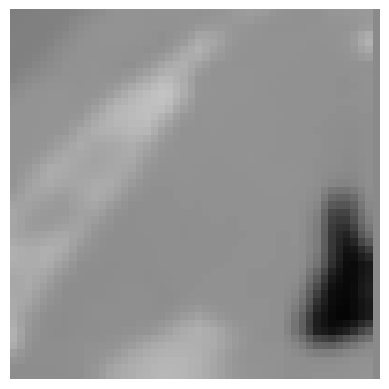

In [10]:
displayImageSlice(cropped_image, 25)